<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme du lagrangien augmenté </h1>
</center>

## Implémentation

1. Implémenter l'algorithme du lagrangien augmenté, en utilisant les différentes méthodes
qui ont été vues en première partie pour la résolution de la suite de problèmes sans
contraintes (fichier `src/lagrangien_augmente.jl`). La spécification est donnée dans le fichier.
2. Vérifier que les tests ci-dessous passent.
 

In [1]:
include("../src/lagrangien_augmente.jl")
include("../test/tester_lagrangien_augmente.jl")

afficher = false

tester_lagrangien_augmente(lagrangien_augmente, afficher);

Affichage des résultats des algorithmes : false

Test Summary:         | Pass  Total  Time
Lagrangien augmenté   |   12     12  5.2s


## Interprétation

1. Commenter les résultats obtenus, en étudiant notamment les valeurs en sortie de $\lambda_k$ et $\mu_k$.

D'un algorithme à l'autre, les $\lambda_k$ et $\mu_k$ sont semblables. C'est cohérent car l'Algorithme n'intervient qu'à une seule étape et les cas choisis ne provoquent pas de dégénérescence. La seule différence notable réside dans le nombre de valeur généré, c'est-à-dire le nombre d'itérations.

À terme, $c(x_k)$ doit tendre vers $0$ donc $\lambda_{k+1} = \lambda_k + \mu_k c(x_k)$ devient constant. De même, $\mu_{k+1}$ finit par ne plus être mis à jour.

Avant cela, $\mu_k$ est mis à jour exponentiellement, par "à-coups" de multiplication par $\tau$, d'où la représentation graphique en escalier.

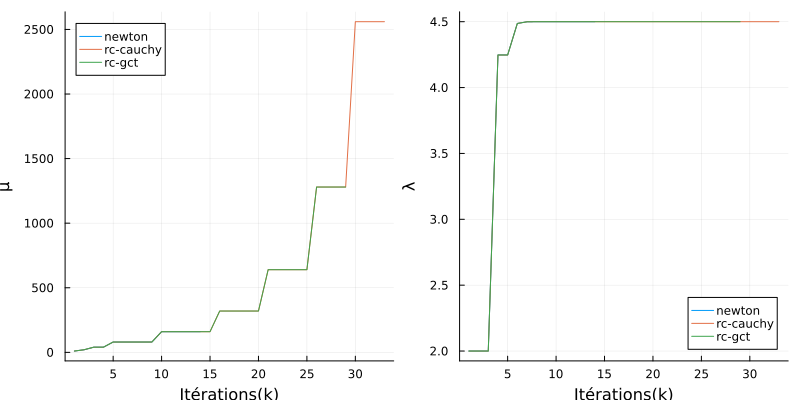

In [2]:
using Plots
include("../src/lagrangien_augmente.jl")

# Fonction f1
# -----------
f1(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2
gradf1(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]); # dérivée /x1
	4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]); # dérivée /x2
	4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])] # dérivée /x3
hessf1(x) = [6 2 4; 2 8 2; 4 2 6]
solution = [1; 1; 1]

# contrainte extraite de test/fonctions_de_tests.jl
c(x) = x[1] + x[3] - 1
gradc(x) = [1; 0; 1]
hessc(x) = [0 0 0; 0 0 0; 0 0 0]

x0 = [0; 1; 1]

pμ = plot(ylabel = "μ", xlabel = "Itérations(k)")
pλ = plot(ylabel = "λ", xlabel = "Itérations(k)")

for algo_noc in ["newton", "rc-cauchy", "rc-gct"]
	x_sol, f_sol, flag, nb_iters, μs, λs = lagrangien_augmente(f1, gradf1, hessf1, c, gradc, hessc, x0, algo_noc = algo_noc)
	plot!(pμ, μs, label = algo_noc)
	plot!(pλ, λs, label = algo_noc)
end

p = plot(pμ, pλ, layout = (1, 2), size = (800, 400), suptitle = "Comparaison des algos utilisés pour le sous-pb sans contrainte")

display(p)


 2. Étudier l'influence du paramètre $\tau$ dans la performance de l'algorithme. Pour cela Vous réaliserez des tests numériques.

Le paramètre $\tau$ est un facteur multiplicatif qui indique de combien on augmente $\mu_k$ lorsque le modèle ne performe pas bien ($||c(x_{k+1}||\gt\eta_k$). On le "pénalise".

Un $\tau$ trop faible ne pénalise pas assez le modèle, qui ignore la contrainte $c$. Un $\tau$ trop élevé force l'algorithme à minimiser $c(x_k)$ plutôt qur $f(x_k)$.

Le premier graphe avec $x_0 = \begin{pmatrix}0 & 0 & 0\end{pmatrix}^\mathrm{T}$ montre bien l'importance de choisir la bonne valeur pour $\tau$.

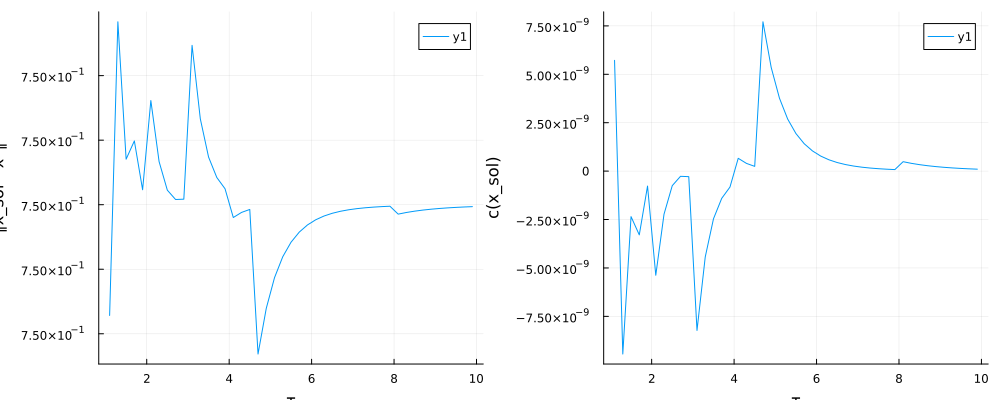

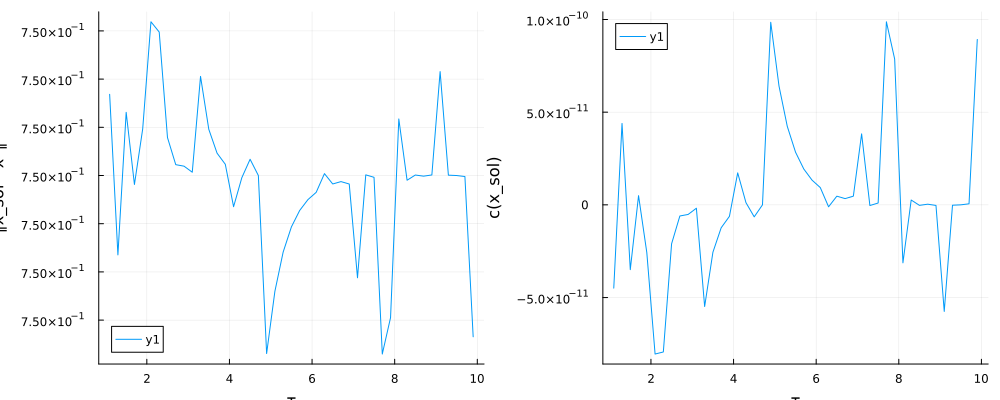

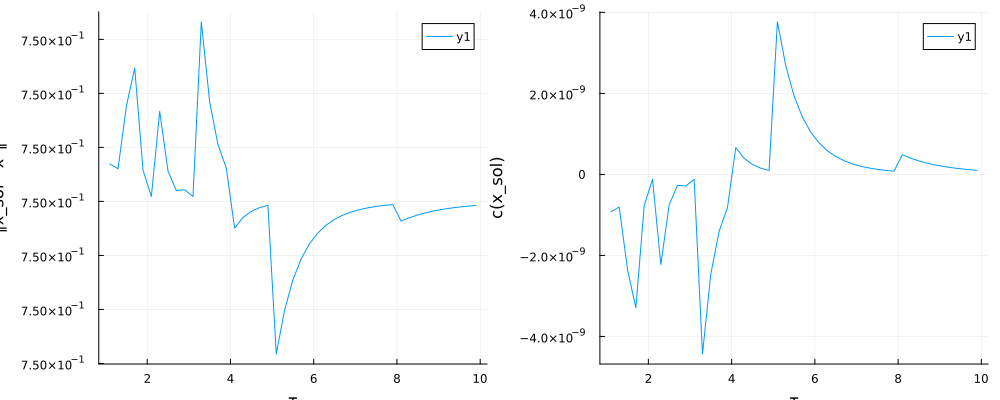

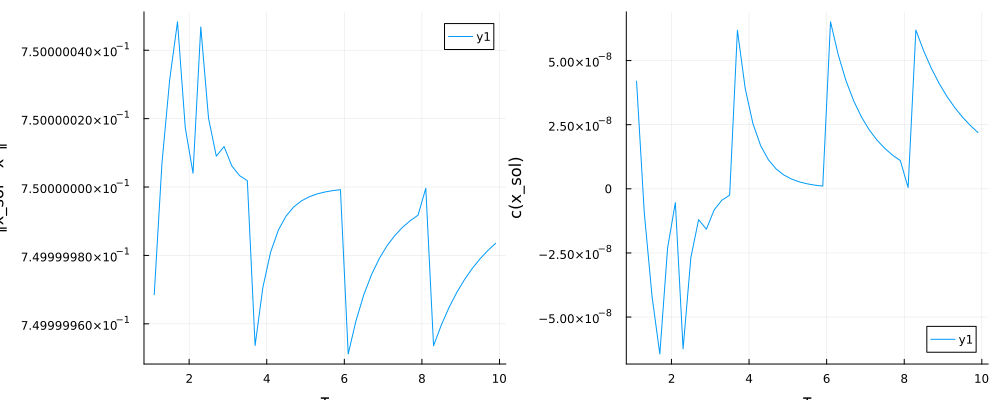

In [4]:
pμ = plot(xlabel = "Itérations(k)", ylabel = "μ")
pλ = plot(xlabel = "Itérations(k)", ylabel = "λ")

x0s = [[0;0;0], [0; 1; 1], [0.5; 1.25; 1],[10; 3; -2.2]]
τs = 1.1:0.2:10
x0 = [0; 0; 0]

for x0 in x0s
	px_sol = plot(xlabel = "τ", ylabel = "∥x_sol - x*∥")
	pcx_sol = plot(xlabel = "τ", ylabel = "c(x_sol)")
	x_sols = []
	for τ in τs
		x_sol, _, _, _, _, _ = lagrangien_augmente(f1, gradf1, hessf1, c, gradc, hessc, x0, τ = τ)
		push!(x_sols, x_sol)
	end
	plot!(px_sol, τs, [norm(solution - x_sol) for x_sol in x_sols])
	plot!(pcx_sol, τs, [c(x_sol) for x_sol in x_sols])
	p = plot(px_sol, pcx_sol, layout = (1, 2), size = (1000, 400), suptitle = "Évolution de perfomance en fonction de τ (x0 = $x0)")
	display(p)
end

